In [2]:
import pandas as pd  # Importing pandas for data manipulation and analysis
import numpy as np  # Importing numpy for numerical operations
import matplotlib.pyplot as plt  # Importing matplotlib for data visualization
import seaborn as sns  # Importing seaborn for statistical data visualization
import warnings  # Importing warnings to handle warning messages
warnings.filterwarnings("ignore")  # Ignoring all warning messages


In [3]:
# df = pd.read_csv('/kaggle/input/housing-prices-dataset/Housing.csv')
# df.head()

In [4]:
# Reading a CSV file from a URL and storing it in a DataFrame
df = pd.read_csv("https://raw.githubusercontent.com/9394113857/Data-Sets/f82f4f9ad22404bd244417b9ab4e5143a2804fcb/Housing.csv")

# The dataset is now loaded into 'df' and can be used for further analysis.


In [5]:
df.head()  # Show the first five rows of the DataFrame


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [6]:
# Generate summary statistics for numerical columns
df.describe()


,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [7]:
# Check for missing values in each column
df.isna().sum()


,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


In [8]:
# Check for missing values and display result only if any are found
missing_values = df.isna().sum()
if missing_values.sum() > 0:
    print(missing_values)
else:
    print("No missing values found.")


No missing values found.


In [9]:
# Count the number of unique values in the 'furnishingstatus' column
df['furnishingstatus'].nunique()


3

In [10]:
# Convert categorical values to numerical for selected columns
columns_to_transform = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']
df[columns_to_transform] = df[columns_to_transform].replace({'yes': 1, 'no': 0})

# Convert 'furnishingstatus' column to numerical representation
df['furnishingstatus'] = df['furnishingstatus'].replace({'unfurnished': 0, 'semi-furnished': 1, 'furnished': 2})

# Code Breakdown - Linewise Explanation 🚀
# columns_to_transform = [...] → Defines a list of categorical columns to be converted.
# df[columns_to_transform].replace({'yes': 1, 'no': 0}) → Uses .replace() to convert 'yes' → 1, 'no' → 0.
# df[columns_to_transform] = ... → Assigns transformed values back to the DataFrame.
# df['furnishingstatus'].replace({...}) → Maps 'unfurnished' → 0, 'semi-furnished' → 1, 'furnished' → 2 using .replace().
# df['furnishingstatus'] = ... → Updates the 'furnishingstatus' column with numerical values.


# Why Convert Categorical Values to Numerical?
Machine learning algorithms can only process numerical data, so categorical values (like 'yes', 'no', 'furnished', etc.) must be converted into numerical representations before training.

# What Could the Categorical Values Be?

## Binary Categorical Values:
- Example: 'yes' → 1, 'no' → 0
- Used for columns like 'mainroad', 'guestroom', 'basement', etc.

## Ordinal Categorical Values (Ordered Categories):
- Example: 'unfurnished' → 0, 'semi-furnished' → 1, 'furnished' → 2
- Since 'furnished' is a higher level than 'semi-furnished', this mapping makes sense.

# Purpose:
This transformation allows algorithms to interpret categorical features correctly during training and prediction. 🚀


# Code Explanation in Points:

1. **Selecting Columns to Convert:**
   - `columns_to_transform = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']`
   - These columns contain categorical values (`'yes'`, `'no'`).

2. **Replacing 'yes' and 'no' with 1 and 0:**
   - `df[columns_to_transform] = df[columns_to_transform].replace({'yes': 1, 'no': 0})`
   - `'yes'` is replaced with `1` and `'no'` with `0`.

3. **Converting 'furnishingstatus' to Numerical Values:**
   - `df['furnishingstatus'] = df['furnishingstatus'].replace({'unfurnished': 0, 'semi-furnished': 1, 'furnished': 2})`
   - `'unfurnished' → 0`, `'semi-furnished' → 1`, `'furnished' → 2`.

---

# Why Convert Categorical Values to Numerical?

✅ **Machine Learning Models Need Numbers:**
   - Models work with numerical data, not text.
✅ **Improves Model Understanding:**
   - Helps algorithms recognize patterns in categorical data.
✅ **Avoids Errors in Training:**
   - Text values (`'yes'`, `'no'`) cause errors in mathematical calculations.
✅ **Ordinal Data Gets Meaningful Order:**
   - `'furnished' > 'semi-furnished' > 'unfurnished'` makes sense numerically (`2 > 1 > 0`).

---

# What If We Don't Convert?

❌ **Machine Learning Model Will Fail:**
   - Many models don’t support categorical text values.
❌ **Errors in Mathematical Operations:**
   - Cannot perform calculations like regression on text.
❌ **No Logical Order for Categories:**
   - `'furnished'`, `'semi-furnished'`, `'unfurnished'` won’t have an understood ranking.

---

# What Happens After Conversion?

✅ **Model Trains Correctly:**
   - Learns patterns between categorical features and the target variable.
✅ **Enables Better Predictions:**
   - Numerical values allow models to interpret relationships.
✅ **Avoids Data Processing Errors:**
   - Smooth data processing without unexpected crashes.

This conversion **ensures proper training, avoids errors, and helps the model learn efficiently**. 🚀


In [11]:
from sklearn.preprocessing import StandardScaler  # Import StandardScaler from sklearn's preprocessing module

scaler = StandardScaler()  # Create an instance of StandardScaler for feature scaling
sc = ['price', 'area']  # Define the list of columns to scale
df[sc] = scaler.fit_transform(df[sc])  # Apply StandardScaler: scales 'price' and 'area' to have mean = 0 and std = 1


### Understanding the Import Statement 🚀

- **`sklearn`** → The **Scikit-Learn** library for machine learning.  
- **`preprocessing`** → A **module** inside Scikit-Learn for data transformation (scaling, normalization, encoding, etc.).  
- **`StandardScaler`** → A **class** from `preprocessing` that standardizes numerical data by removing the mean and scaling to unit variance.  

### Meaning of Import Statement:  
👉 `from sklearn.preprocessing import StandardScaler`  
This imports the **`StandardScaler`** class from the **`preprocessing`** module of Scikit-Learn, allowing us to perform feature scaling. 🚀


### What You Used It For? 🚀  

👉 You used **StandardScaler** to scale **price** and **area** so their values are centered around **0** and have a **standard deviation of 1**.  
This prevents one feature from overpowering another.  



### **Why Are We Fitting These Columns?**  
1. **To Standardize Values** → Ensures `price` and `area` have mean **0** and standard deviation **1**.  
2. **Avoids Feature Domination** → Prevents large values (e.g., price in lakhs) from overpowering small ones.  
3. **Helps ML Models** → Many algorithms perform better with standardized data (e.g., Gradient Descent).  
4. **Prepares for Model Training** → Scaled data improves model accuracy and stability.  

### **What Can We Learn for Model Building?**  
✔ Standardization is key when features have different scales.  
✔ Essential for models like **Logistic Regression, KNN, SVM, PCA**.  
✔ Helps in faster convergence during training. 🚀  


### **Yes! ✅ Scaling is Important for Model Performance**  
Scaling (like using **StandardScaler**) ensures that numerical features (**price, area, etc.**) are transformed into a **standard range** (mean = 0, standard deviation = 1).  

### **Why Does Scaling Matter for Model Building?**  
✔ **Faster Training** → Gradient Descent converges quicker.  
✔ **Better Accuracy** → Prevents one feature from dominating others.  
✔ **Improves Stability** → Helps avoid numerical instability in complex models.  
✔ **Essential for ML Algorithms** → Especially for **SVM, KNN, Logistic Regression, PCA, and Neural Networks**.  

### **What Does Scaling Do?**  
🔹 Standardizes features (**mean = 0, standard deviation = 1**).  
🔹 Ensures numerical values are on the **same scale** for effective learning.  
🔹 Helps machine learning models **train efficiently** and make better predictions. 🚀  


In [12]:
# Display the DataFrame
df


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,4.566365,1.046726,4,2,3,1,0,0,0,1,2,1,2
1,4.004484,1.757010,4,4,4,1,0,0,0,1,3,0,2
2,4.004484,2.218232,3,2,2,1,0,1,0,0,2,1,1
3,3.985755,1.083624,4,2,2,1,0,1,0,1,3,1,2
4,3.554979,1.046726,4,1,2,1,1,1,0,1,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,-1.576868,-0.991879,2,1,1,1,0,1,0,0,2,0,0
541,-1.605149,-1.268613,3,1,1,0,0,0,0,0,0,0,1
542,-1.614327,-0.705921,2,1,1,1,0,0,0,0,0,0,0
543,-1.614327,-1.033389,3,1,1,0,0,0,0,0,0,0,2


In [13]:
# Display data types of each column in the DataFrame
df.dtypes


,0
price,float64
area,float64
bedrooms,int64
bathrooms,int64
stories,int64
mainroad,int64
guestroom,int64
basement,int64
hotwaterheating,int64
airconditioning,int64


### **Understanding Data Types: float64 & int64**  

- **float64** → Represents **decimal (floating-point) numbers**, used for continuous values.  
  *Example: Price, Area, Ratings (e.g., 1250.75, 99.99, etc.)*  

- **int64** → Represents **whole (integer) numbers**, used for discrete values.  
  *Example: Number of Rooms, Floors, Age of Property (e.g., 1, 5, 10, etc.)*  


# Get Current Local IST Time in Bold with AM/PM

In [14]:
# Cell 1: Get **Current Local IST Time**

# Import necessary libraries
from datetime import datetime
import pytz

# Define the IST timezone
ist = pytz.timezone('Asia/Kolkata')

# Get the current time in IST
current_time_ist = datetime.now(ist)

# Format the time with AM/PM in bold
formatted_time = f"**{current_time_ist.strftime('%Y-%m-%d %I:%M:%S %p')}**"

# Print the current IST time in bold format
from IPython.display import display, Markdown
display(Markdown(f"Current **IST Time**: {formatted_time}"))


Current **IST Time**: **2025-02-12 02:10:53 PM**

In [15]:
# Compute the correlation matrix for the DataFrame
corr_matrix = df.corr()


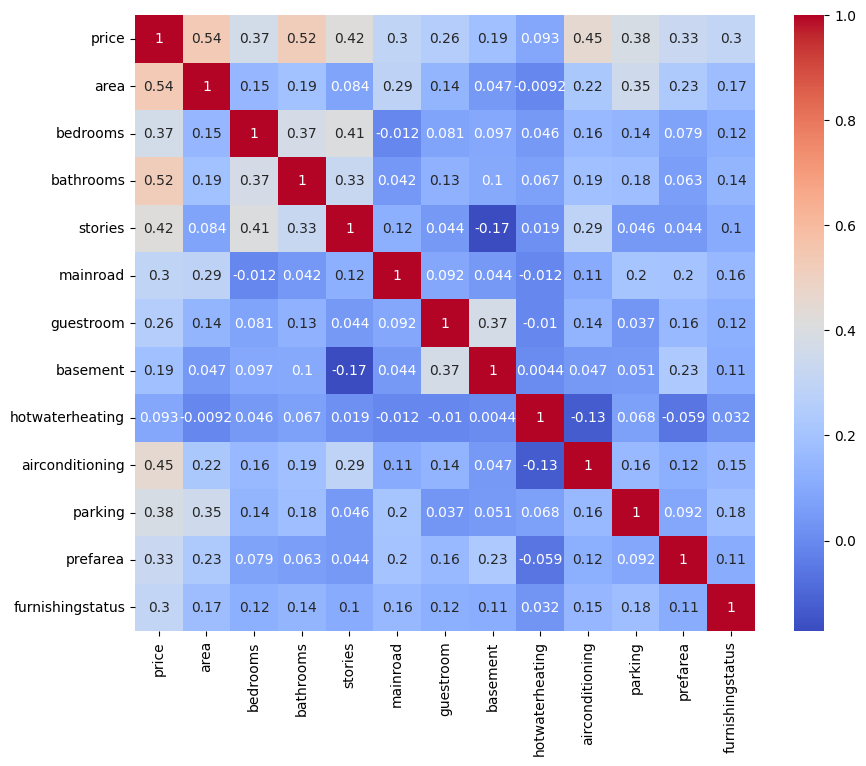

In [16]:
# Set the figure size for better visibility
plt.figure(figsize=(10, 8))

# Create a heatmap to visualize the correlation matrix
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

# Display the plot
plt.show()


### 🔹 Understanding Correlation Matrix & Heatmap  

1️⃣ **Computing Correlation Matrix (`df.corr()`)**  
   - Measures relationships between numerical columns.  
   - Values range from **-1 to 1**:  
     - **1** → Strong positive correlation (both increase together).  
     - **0** → No correlation (independent variables).  
     - **-1** → Strong negative correlation (one increases, the other decreases).  

2️⃣ **Visualizing Correlation Using Heatmap (`sns.heatmap()`)**  
   - Provides a color-coded representation of correlation values.  
   - Darker shades indicate **stronger correlations**.  
   - Helps identify features that are strongly related (useful for feature selection).  

📌 **Final Insight:**  
- High correlation → Possible redundancy in features.  
- Low correlation → Independent variables, good for modeling.  


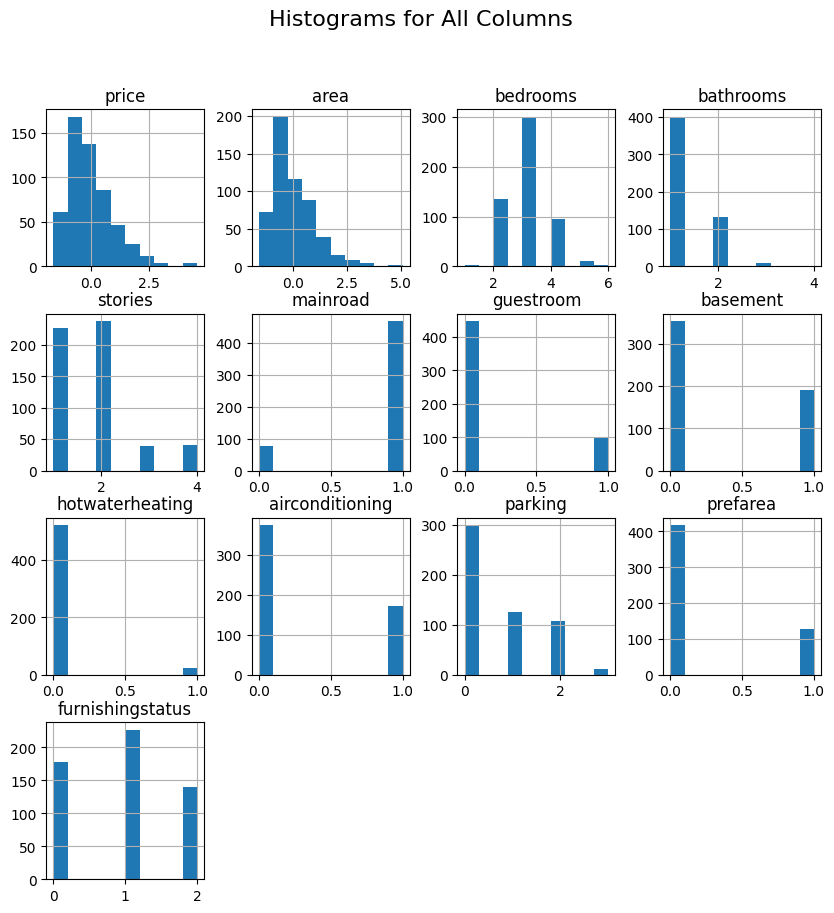

In [17]:
# Create histograms for all numerical columns in the DataFrame
df.hist(figsize=(10, 10), bins=10)

# Add a title to the entire figure
plt.suptitle("Histograms for All Columns", fontsize=16)

# Display the plot
plt.show()


### Why Are Histograms Used? 📊  

1. **Understand Data Distribution** – Shows how values in each column are spread (e.g., normal, skewed).  
2. **Identify Outliers** – Helps detect extreme values that might affect model performance.  
3. **Compare Feature Ranges** – Allows checking if features have different scales.  
4. **Detect Skewness** – Helps understand if data needs transformation (e.g., log scaling).  


Continue above points more for what thy used for etc

In [18]:
# Define the feature set (X) by dropping the target variable 'price'
X = df.drop('price', axis=1)

# Define the target variable (y) as the 'price' column
y = df['price']


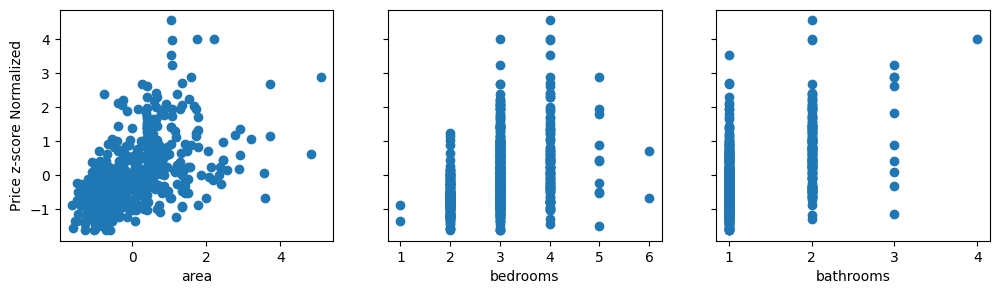

In [19]:
# Define the list of selected features to visualize
X_features = ['area', 'bedrooms', 'bathrooms']

# Create subplots with 1 row and 3 columns, sharing the y-axis
fig, ax = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

# Loop through the selected features and plot scatter plots
for i in range(3):
    ax[i].scatter(X.iloc[:, i], y)  # Scatter plot for each feature vs. price
    ax[i].set_xlabel(X_features[i])  # Set x-axis label as feature name

# Set y-axis label for the first plot
ax[0].set_ylabel("Price z-score Normalized")

# Display the plots
plt.show()


# 📌 Why Use Scatter Plots? What Do We Learn?  

1️⃣ **Visualizes Relationships** 🔍  
   - Shows how each feature (area, bedrooms, bathrooms) relates to price.  

2️⃣ **Identifies Trends** 📈  
   - Helps spot patterns like positive or negative correlations between features and price.  

3️⃣ **Detects Outliers** ⚠️  
   - Points far from the trend indicate unusual data that may need further analysis.  


In [20]:
# Import the train_test_split function from scikit-learn
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
# 80% of data goes to training (X_train, y_train) and 20% to testing (X_test, y_test)
# random_state=42 ensures reproducibility of results
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


### Why Do We Split the Dataset?  
- In **Machine Learning**, we need to evaluate how well a model performs on unseen data.  
- We split the dataset into **training** and **testing** sets to prevent overfitting and ensure reliable evaluation.  
- The **training set** is used to train the model, while the **testing set** helps measure its accuracy on new data.  

### What Does This Code Do?  
- Uses `train_test_split()` to randomly divide the dataset into **80% training** and **20% testing**.  
- The `random_state=42` ensures the split remains the same every time the code runs (for reproducibility).  

### Is There a Rule for Splitting?  
- **Common Splits:**  
  - **80/20 or 70/30** (for standard training/testing).  
  - **90/10** (for large datasets where less test data is needed).  
  - **60/20/20** (for cases needing a validation set).  
- The choice depends on dataset size, model complexity, and the need for validation.  

### What If We Don’t Split?  
- If we train and test on the same data, the model **memorizes patterns** instead of generalizing, leading to **overfitting**.  
- A good split ensures the model **learns meaningful patterns** and performs well on unseen data.  

### What’s Next?  
- After splitting, we train the model on `X_train, y_train` and evaluate it using `X_test, y_test`.  
- We can further improve generalization by using techniques like **cross-validation** and **hyperparameter tuning**.  


In [21]:
# Import the LinearRegression model from scikit-learn
from sklearn.linear_model import LinearRegression

# Create an instance of the LinearRegression model
lr_model = LinearRegression()

# Train (fit) the model using the training data (X_train, y_train)
lr_model.fit(X_train, y_train)

# Predict the target variable (price) using the test data (X_test)
y_pred = lr_model.predict(X_test)


Continue

In [22]:
# Import DecisionTreeRegressor for regression modeling
from sklearn.tree import DecisionTreeRegressor

# Import GridSearchCV for hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# Create an instance of DecisionTreeRegressor with a fixed random state
dt_model = DecisionTreeRegressor(random_state=42)

# Define a dictionary containing hyperparameters and their possible values for tuning
param_grid = {
    'max_depth': [5, 10, 15, 20],  # Maximum depth of the tree
    'min_samples_split': [2, 5, 10],  # Minimum number of samples required to split a node
    'min_samples_leaf': [1, 5, 10],  # Minimum number of samples required in a leaf node
    'max_features': ['auto', 'sqrt', 'log2'],  # Number of features to consider when making a split
    'criterion': ['squared_error', 'friedman_mse', 'poisson', 'absolute_error']  # Loss functions to measure the quality of splits
}

# Perform Grid Search with cross-validation (cv=5) to find the best hyperparameters
grid_search = GridSearchCV(estimator=dt_model, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the grid search model using the training dataset
grid_search.fit(X_train, y_train)

# Print the best parameters obtained from GridSearchCV
print("Best Parameters:", grid_search.best_params_)

# Get the best Decision Tree model with optimized hyperparameters
best_dt_model = grid_search.best_estimator_


Best Parameters: {'criterion': 'absolute_error', 'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 2}


### Purpose & Explanation:
- **Why use DecisionTreeRegressor?**  
  - It models complex, non-linear relationships by splitting the data into decision-based segments.  
  - Unlike Linear Regression, it captures intricate patterns and interactions in the dataset.  

- **What does this code do?**  
  - Uses **GridSearchCV** to find the best hyperparameters for a Decision Tree model.  
  - Trains multiple models using different hyperparameter combinations.  
  - Evaluates each model using **5-fold cross-validation** and selects the best-performing one.  

- **What do the parameters mean?**  
  - `max_depth`: Limits tree depth to prevent overfitting.  
  - `min_samples_split`: Controls the minimum samples needed to split a node.  
  - `min_samples_leaf`: Ensures leaf nodes have a minimum number of samples.  
  - `max_features`: Determines how many features are considered at each split.  
  - `criterion`: Specifies the loss function used to measure split quality.  

- **What do the results tell us?**  
  - `grid_search.best_params_` gives the optimal values for hyperparameters.  
  - `best_dt_model` is the final model trained with the best hyperparameters.  

- **What can we do next?**  
  - Use `best_dt_model` to make predictions and compare its performance with other models.  
  - If the model overfits, consider limiting depth or adjusting `min_samples_split`.  
  - If performance is poor, explore feature engineering or ensemble methods like **Random Forest**.  


In [23]:
# Predict target values (price) using the trained Linear Regression model
lr_y_pred = lr_model.predict(X_test)

# Predict target values (price) using the best-tuned Decision Tree model
dt_y_pred = best_dt_model.predict(X_test)


In [24]:
# Import r2_score to evaluate model performance
from sklearn.metrics import r2_score

# Calculate R² score (coefficient of determination) for Linear Regression model
lr_acc = r2_score(y_test, lr_y_pred)

# Calculate R² score for Decision Tree model
dt_acc = r2_score(y_test, dt_y_pred)

# Print the accuracy scores of both models
print(f"Linear Regression Accuracy: {lr_acc}")
print(f"Decision Tree Accuracy: {dt_acc}")


Linear Regression Accuracy: 0.6494754192267794
Decision Tree Accuracy: 0.4928485257199178


### Purpose & Explanation:
- **Why use R² score (r2_score)?**  
  - R² (coefficient of determination) measures how well the model explains the variance in the target variable.  
  - A higher R² value (closer to 1) indicates a better model fit.  

- **What does this code do?**  
  - Computes the R² score for both **Linear Regression** and **Decision Tree** models.  
  - Compares how well each model predicts the target values.  

- **What do the results tell us?**  
  - If `lr_acc` is higher than `dt_acc`, Linear Regression explains the variance better.  
  - If `dt_acc` is higher, the Decision Tree model captures patterns better.  
  - A very low R² suggests the model is not fitting well and may need improvement.  

- **What can we do next?**  
  - If accuracy is low, consider **feature engineering, hyperparameter tuning, or trying other models**.  
  - If the Decision Tree performs better, we might tune its depth or try more complex models like Random Forest.  
  - If both models perform poorly, checking for **data preprocessing issues** (e.g., missing values, outliers) is necessary.  


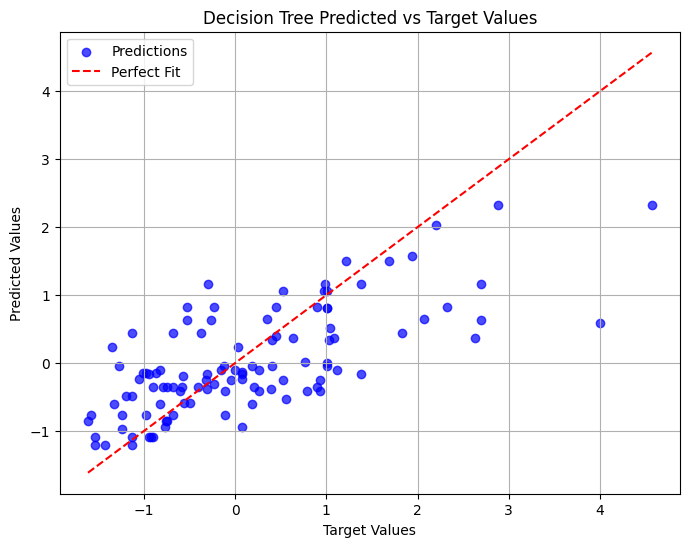

In [26]:
# Set the figure size for better visualization
plt.figure(figsize=(8, 6))

# Create a scatter plot of actual target values vs. predicted values for the Decision Tree model
plt.scatter(y_test, dt_y_pred, color='blue', alpha=0.7, label='Predictions')

# Plot a diagonal reference line representing a perfect prediction scenario
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', label='Perfect Fit')

# Set the x-axis label
plt.xlabel('Target Values')

# Set the y-axis label
plt.ylabel('Predicted Values')

# Set the plot title
plt.title('Decision Tree Predicted vs Target Values')

# Add a legend to differentiate between predictions and the perfect fit line
plt.legend()

# Enable grid for better readability
plt.grid(True)

# Display the plot
plt.show()


### Purpose & Explanation:
- **Why use a scatter plot?**  
  - Helps visualize how well the model's predictions align with actual target values.  
  - Each point represents a comparison between an actual and predicted value.  

- **What does the reference line indicate?**  
  - The red dashed line represents a **perfect fit** (i.e., ideal predictions where `Predicted = Actual`).  
  - If predictions were perfect, all points would lie on this line.  

- **What insights can we gain?**  
  - Points **closer to the red line** indicate better predictions.  
  - Large deviations suggest errors, highlighting areas where the model may struggle.  

- **Why enable a grid and use labels?**  
  - Grid lines enhance readability and make patterns easier to spot.  
  - Axis labels and the title clarify what the plot represents.  

- **Why compare different models?**  
  - This visualization helps compare the Decision Tree model's performance to other regression models.  
  - By creating similar scatter plots for different models, we can determine which one provides better predictions.  


<font size="5">**Gradient Descent**</font>

In [27]:
# Import the Stochastic Gradient Descent (SGD) Regressor from scikit-learn
from sklearn.linear_model import SGDRegressor

# Initialize the SGDRegressor model with a maximum of 1000 iterations
sgdr = SGDRegressor(max_iter=1000)

# Train (fit) the SGDRegressor model on the training data
sgdr.fit(X_train, y_train)

# Print the model details
print(sgdr)

# Print the number of iterations completed and the total number of weight updates
print(f"Number of iterations completed: {sgdr.n_iter_}, Number of weight updates: {sgdr.t_}")


SGDRegressor()
Number of iterations completed: 46, Number of weight updates: 20057.0


### What This Code Does:
- **SGDRegressor** is a linear model that optimizes using stochastic gradient descent.  
- **Fitting the model** updates the weights based on training data (`X_train`, `y_train`).  
- **`n_iter_`** tells us how many passes over the data were completed.  
- **`t_`** represents the number of weight updates during training.  


In [28]:
# Retrieve the intercept (bias) term of the trained SGDRegressor model
b_norm = sgdr.intercept_

# Retrieve the coefficient (weights) of the features in the trained model
w_norm = sgdr.coef_

# Print the model parameters (weights and bias)
print(f"Model Parameters: w: {w_norm}, b: {b_norm}")


Model Parameters: w: [ 0.32967649 -0.10789347  0.48126295  0.22559117 -0.10649311  0.13312004
  0.20685312  0.21928683  0.43871452  0.12699044  0.33345066  0.09923402], b: [-1.11843538]


In [29]:
# Predict target values for the training set using the trained SGDRegressor model
y_pred_sgd = sgdr.predict(X_train)

# Manually compute predictions using the learned weights and bias
y_pred = np.dot(X_train, w_norm) + b_norm

# Check if predictions from np.dot() and sgdr.predict() match exactly
print(f"Prediction using np.dot() and sgdr.predict match: {(y_pred == y_pred_sgd).all()}")

# Display the first four predicted values
print(f"Prediction on training set:\n{y_pred[:4]}")

# Display the first four actual target values
print(f"Target values \n{y_train[:4]}")


Prediction using np.dot() and sgdr.predict match: True
Prediction on training set:
[ 1.20961859  1.07691026  0.16123247 -0.46216015]
Target values 
46     1.476019
93     0.820491
335   -0.453106
412   -0.715317
Name: price, dtype: float64


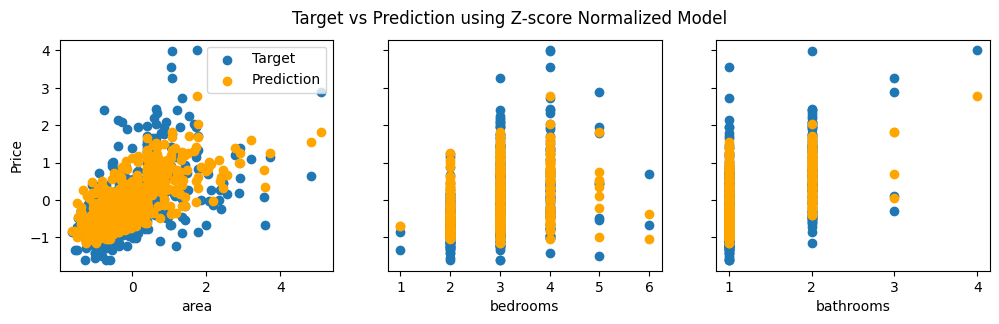

In [30]:
# Create a figure with 1 row and 3 columns of subplots, sharing the y-axis
fig, ax = plt.subplots(1, 3, figsize=(12, 3), sharey=True)

# Loop through each subplot to plot the target and predicted values
for i in range(len(ax)):
    # Scatter plot for actual target values
    ax[i].scatter(X_train.iloc[:, i], y_train, label='Target')
    ax[i].set_xlabel(X_features[i])  # Label the x-axis with feature names

    # Scatter plot for predicted values in orange
    ax[i].scatter(X_train.iloc[:, i], y_pred, color="orange", label='Prediction')

# Label the first subplot's y-axis and add a legend
ax[0].set_ylabel("Price")
ax[0].legend()

# Set a title for the entire figure
fig.suptitle("Target vs Prediction using Z-score Normalized Model")

# Display the plot
plt.show()


### Purpose & Explanation:
- **Why use `subplots`?**  
  - `plt.subplots(1,3,figsize=(12,3),sharey=True)` creates multiple plots in a single figure for easier comparison.  
  - It allows us to visualize relationships between different features and the target variable (`Price`).  
  - `sharey=True` ensures all subplots have the same y-axis scale for consistency.  

- **What does the loop do?**  
  - Iterates through each subplot (`ax[i]`) and plots:  
    - **Actual target values (`y_train`)** in blue.  
    - **Predicted values (`y_pred`)** in orange to compare model predictions.  

- **How are labels & legends handled?**  
  - Each subplot's x-axis is labeled with the corresponding feature name.  
  - The first subplot has a y-axis label (`Price`) for clarity.  
  - A legend is included to differentiate actual vs. predicted values.  

- **Why add a title?**  
  - The title, "Target vs. Prediction using Z-score Normalized Model," helps interpret the comparison.  

- **Final Step: `plt.show()`**  
  - Displays the scatter plots to analyze how well the model predicts the target variable across different features.  
